# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [3]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup, data_utils
from src.models import bert

/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## B. Data

### B.1. Load sets

In [44]:
data_frac = data_utils.DATA_FRACTION

df_train, df_val, df_test = data_utils.load_datasets()

### B.2. Shrink dataset size for development purpose

In [45]:
# # Comment out this cell to use the full dataset. This is just for quick testing.
# train_size = 100
# val_size = int(train_size * len(df_val) / len(df_train))
# test_size = int(train_size * len(df_test) / len(df_train))

# df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
# df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
# df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)

In [46]:
# Load data as Hugging Face Datasets
ds_train, ds_val, ds_test = bert.create_datasets(df_train, df_val, df_test)

## C. Tokenization

In [47]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [48]:
bert.max_length_dist(df_train, 'tweet_text', tokenizer)

90th percentile: 47.0
95th percentile: 52.0
99th percentile: 64.78999999999996
Absolute Maximum length: 86


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [49]:
save_path = Path(f"../tokens/BERT/{data_frac}")
train_tokenized, val_tokenized, test_tokenized = bert.load_or_tokenize(
    ds_train, ds_val, ds_test, tokenizer, save_path
    , force_retokenize=True
)

Tokenizing datasets...


Map: 100%|██████████| 2191/2191 [00:00<00:00, 16124.89 examples/s]


Saving tokenized datasets to ../tokens/BERT/0.1...


Saving the dataset (1/1 shards): 100%|██████████| 2191/2191 [00:00<00:00, 370987.04 examples/s]


## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

### B.1. Preparation

In [52]:
device = setup.setup_device_with_seeds()

batch_size = 16
learning_rate = 5e-5
num_epochs = 5
patience = 2  # early stopping, if validation loss does not improve for this many epochs

train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

Using device: mps


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [53]:
model, train_loss_history, val_loss_history, val_acc_history = bert.finetune(train_tokenized, val_tokenized, configs)

Starting BertForSequenceClassification fine-tuning...
Using device: mps
Number of training samples: 10224
Number of validation samples: 2191
Batch size: 16
Number of epochs: 5
Early stopping patience: 2 epochs
--------------------------------------------------


Validating Epoch 1/5: 100%|██████████| 137/137 [00:24<00:00,  5.67it/s]


Epoch 1/5 | Train Loss: 0.2174 | Val Loss: 0.1809 | Val Acc: 0.9251


Validating Epoch 2/5: 100%|██████████| 137/137 [00:18<00:00,  7.34it/s]


Epoch 2/5 | Train Loss: 0.1238 | Val Loss: 0.1785 | Val Acc: 0.9274


Validating Epoch 3/5: 100%|██████████| 137/137 [00:19<00:00,  7.07it/s]


Epoch 3/5 | Train Loss: 0.0580 | Val Loss: 0.2736 | Val Acc: 0.9297


Validating Epoch 4/5: 100%|██████████| 137/137 [00:21<00:00,  6.24it/s]


Epoch 4/5 | Train Loss: 0.0382 | Val Loss: 0.2812 | Val Acc: 0.9274
Early stopping triggered at epoch 4.
Loaded best model with Val Loss: 0.1785


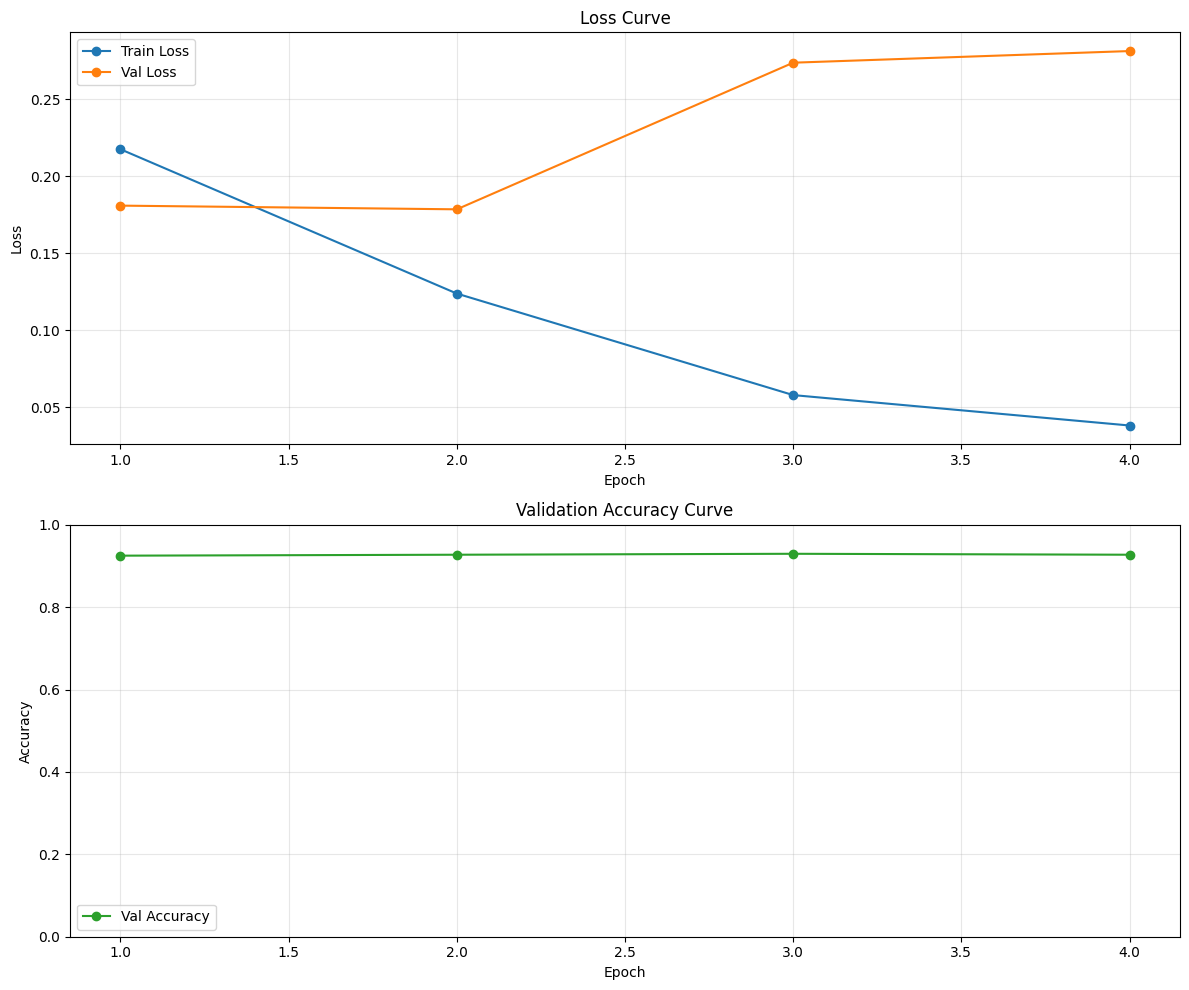

In [54]:
data_utils.plot_fine_tune_history(train_loss_history, val_loss_history, val_acc_history)

### B.3. Predict on the Test set

In [55]:
predictions = bert.predict(model, test_tokenized, device)

Predicting on Test Set: 100%|██████████| 137/137 [00:22<00:00,  5.97it/s]


In [56]:
bert.report_metrics(test_tokenized, predictions)


Classification report:
              precision    recall  f1-score   support

       False     0.9545    0.9594    0.9570      1553
        True     0.9000    0.8887    0.8943       638

    accuracy                         0.9388      2191
   macro avg     0.9273    0.9241    0.9256      2191
weighted avg     0.9386    0.9388    0.9387      2191



In [57]:
data_utils.group_report_metrics(df_test, predictions, group_by="subset", labels="informative")

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.7649    0.8077    0.7857       286
        True     0.9116    0.8887    0.9000       638

    accuracy                         0.8636       924
   macro avg     0.8382    0.8482    0.8429       924
weighted avg     0.8662    0.8636    0.8646       924

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9843    0.9921       508
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9843       508
   macro avg     0.5000    0.4921    0.4960       508
weighted avg     1.0000    0.9843    0.9921       508

 Classification Report for Subset: weather
--------------------------------------------------
              precision    recall  f1-score   support

      

/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,